# Anomaly Detection in Industrial Processes (SECOM Dataset)

## Overview

This project focuses on detecting abnormal operating conditions in a high-dimensional industrial manufacturing process using unsupervised learning techniques.

Unlike traditional predictive models, this approach does not rely on labeled failure data. Instead, it identifies patterns that deviate from normal behavior, enabling early detection of potential issues before defects occur.

---

## Objective

The main objective is to:

- Detect anomalies in process variables using unsupervised learning  
- Identify abnormal operating conditions in high-dimensional data  
- Evaluate whether detected anomalies are associated with actual failures  
- Compare anomaly detection with traditional failure-based approaches  

---

## Dataset

**SECOM Manufacturing Dataset**

The dataset contains sensor measurements collected from a semiconductor manufacturing process.

Key characteristics:

- ~590 process variables (sensors)  
- High dimensionality  
- Presence of missing values  
- Binary target variable (Pass/Fail)  

Although a failure label exists, it will not be used during model training, allowing the anomaly detection model to operate independently of labeled outcomes.

---

## Approach

The project will follow these steps:

1. Data loading and initial exploration  
2. Data cleaning and handling missing values  
3. Feature selection and dimensionality reduction  
4. Anomaly detection using Isolation Forest  
5. Evaluation of detected anomalies against failure labels  
6. Interpretation of abnormal conditions  

---

## Key Idea

Failures in industrial processes are rarely caused by a single variable.  
They emerge from complex interactions across multiple process conditions.

This project aims to capture these multivariate patterns and identify when the system deviates from normal behavior.

In [2]:
import pandas as pd

# cargar dataset
df = pd.read_csv('uci-secom.csv')


# ver primeras filas
df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [3]:
df.shape

(1567, 592)

In [4]:
df['Pass/Fail'].value_counts()


-1    1463
 1     104
Name: Pass/Fail, dtype: int64

In [5]:
df['Failure'] = df['Pass/Fail'].apply(lambda x: 1 if x == 1 else 0)

df['Failure'].value_counts()

0    1463
1     104
Name: Failure, dtype: int64

## Target Distribution

The dataset contains a binary outcome variable indicating product quality:

- 0 → Normal operation (Pass)  
- 1 → Failure (Defective product)  

The data is highly imbalanced, with failures representing a small fraction of observations (~7%).

This reflects real manufacturing environments, where defective products are relatively rare events.

In [7]:
missing_ratio = df.isnull().mean()

missing_ratio.describe()

count    593.000000
mean       0.045146
std        0.153982
min        0.000000
25%        0.001276
50%        0.003829
75%        0.005743
max        0.911934
dtype: float64

In [8]:
threshold = 0.5

cols_to_keep = missing_ratio[missing_ratio < threshold].index

df = df[cols_to_keep]

df.shape

(1567, 565)

In [9]:
missing_ratio = df.isnull().mean()

missing_ratio.describe()

count    565.000000
mean       0.013196
std        0.048604
min        0.000000
25%        0.000638
50%        0.003829
75%        0.005743
max        0.456286
dtype: float64

In [10]:
# imputacion de faltantes
df = df.fillna(df.median())
df.isnull().sum().sum()

C:\Users\polo6\AppData\Local\Temp\ipykernel_1360\2255832468.py:2: FutureWarning: The default value of numeric_only in DataFrame.median is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df = df.fillna(df.median())


0

In [11]:
# Separacion de variables
X = df.drop(columns=['Pass/Fail', 'Failure'])
y = df['Failure']

In [12]:
# Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = X.select_dtypes(include=['number'])

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(1567, 562)

In [13]:
# Modelo de anomalías (Isolation Forest)

from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.07,   # alineado con ~7% fallas reales
    random_state=42
)

model.fit(X_scaled)

# predicción
df['anomaly'] = model.predict(X_scaled)

C:\Users\polo6\AppData\Local\Temp\ipykernel_1360\2007614024.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['anomaly'] = model.predict(X_scaled)


In [14]:
df['anomaly'].value_counts()

 1    1457
-1     110
Name: anomaly, dtype: int64

In [15]:
pd.crosstab(df['anomaly'], df['Failure'])

Failure,0,1
anomaly,,
-1,95,15
1,1368,89


In [16]:
df.groupby('anomaly')[X.columns].mean().T.head(10)

anomaly,-1,1
0,2996.774727,3015.775353
1,2504.698455,2495.199290
2,2204.835253,2200.228580
3,1505.697047,1387.055064
4,1.394667,4.380908
5,100.000000,100.000000
6,99.988516,101.201634
7,0.121145,0.121876
8,1.473164,1.462082
9,-0.001838,-0.000766


In [17]:
df.groupby(['anomaly', 'Failure']).size()

anomaly  Failure
-1       0            95
         1            15
 1       0          1368
         1            89
dtype: int64

## Anomaly Detection vs Actual Failures

To evaluate the effectiveness of the anomaly detection model, the predicted anomalies were compared against actual failure outcomes.

### Key Results

- Total failures: 104  
- Failures detected as anomalies: 15  
- Detection rate (recall): ~14%  

### Interpretation

The Isolation Forest model identifies approximately 7% of observations as anomalous, consistent with the expected contamination level.

However, only a small portion of actual failures are classified as anomalies.

### Key Insight

Anomalies do not fully overlap with failure conditions.

- Many anomalies correspond to unusual but non-failing conditions  
- Most failures occur within what appears to be normal operating behavior  

### Industrial Implication

This suggests that:

- Not all failures are preceded by extreme or abnormal signals  
- Some defects may arise within normal operating ranges  
- Anomaly detection alone is not sufficient for failure prediction  

### Conclusion

Anomaly detection is useful for identifying unusual process behavior, but it should be combined with supervised models and process control strategies to effectively detect and prevent failures.

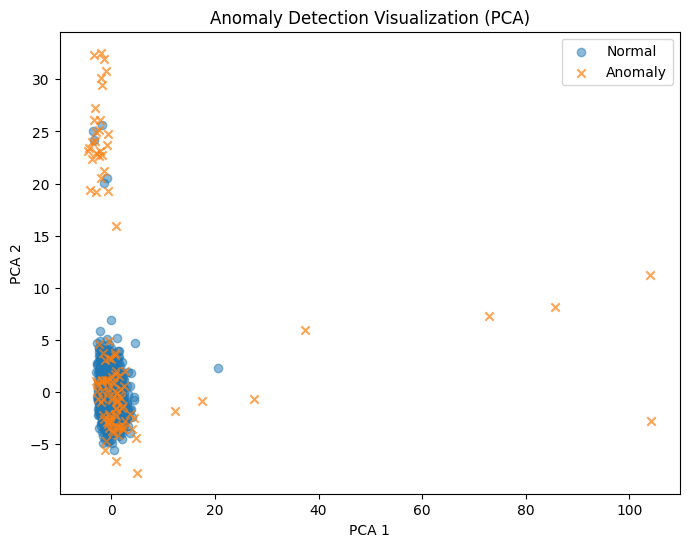

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# reducir a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# gráfica
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[df['anomaly'] == 1, 0],
    X_pca[df['anomaly'] == 1, 1],
    alpha=0.5,
    label='Normal'
)

plt.scatter(
    X_pca[df['anomaly'] == -1, 0],
    X_pca[df['anomaly'] == -1, 1],
    alpha=0.7,
    label='Anomaly',
    marker='x'
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Anomaly Detection Visualization (PCA)')
plt.legend()

plt.show()

## Visualization of Anomalies (PCA)

To better understand the behavior of detected anomalies, dimensionality reduction was applied using Principal Component Analysis (PCA).

The high-dimensional data was projected into a 2D space to visualize the distribution of normal and anomalous observations.

### Observations

- Most normal observations form a dense cluster, representing stable process conditions  
- Some anomalies are clearly separated from this cluster, indicating strong deviations  
- However, a significant portion of anomalies overlaps with normal data  

### Interpretation

This suggests that:

- Certain abnormal conditions are easily identifiable as extreme outliers  
- Other anomalies are subtle and lie within the normal operating region  
- Not all deviations from normal behavior are clearly separable in reduced dimensions  

### Conclusion

Anomaly detection is effective in identifying extreme deviations, but may struggle to distinguish subtle variations that lead to failure.

This reinforces the need to combine anomaly detection with other approaches such as supervised learning and process control methods.

## Explorar con random forest

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# modelo
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

# Feature importance

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

top_features = feature_importance.sort_values(ascending=False).head(10)

top_features




# predicción
y_pred = rf.predict(X_test)

# reporte
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



C:\Users\polo6\anaconda3\envs\dataprep_env\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\polo6\anaconda3\envs\dataprep_env\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\polo6\anaconda3\envs\dataprep_env\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [23]:
top_features

59     0.013757
103    0.013650
519    0.011048
130    0.010561
33     0.010076
205    0.009201
341    0.009118
31     0.008587
477    0.008396
129    0.007647
dtype: float64

### Feature Importance

The Random Forest model identifies several variables with relatively higher importance in distinguishing between normal and failure conditions.

However, the importance is distributed across multiple features, with no single variable dominating the model.

This suggests that failures are not driven by a specific sensor or parameter, but rather by complex interactions across multiple process variables.

This observation is consistent with the nature of industrial processes, where defects often emerge from multivariate conditions rather than isolated signals.

In [25]:
y_prob = rf.predict_proba(X_test)[:, 1]

import numpy as np

y_pred_custom = (y_prob > 0.1).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91       293
           1       0.16      0.33      0.22        21

    accuracy                           0.84       314
   macro avg       0.56      0.61      0.57       314
weighted avg       0.90      0.84      0.87       314



### Threshold Selection

A lower classification threshold (0.1) was selected to improve the detection of failure events.

Given the highly imbalanced nature of the dataset and the high cost of missed failures, the model is adjusted to prioritize recall over precision.

This approach increases the number of detected failures, at the expense of generating more false positives, which is often an acceptable trade-off in industrial settings where early detection is critical.

In [26]:
# Regresion logistica

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced')

lr.fit(X_train, y_train)

y_prob_lr = lr.predict_proba(X_test)[:, 1]



# mismo threshold que RF
y_pred_lr = (y_prob_lr > 0.1).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.94      0.80      0.87       293
           1       0.09      0.29      0.14        21

    accuracy                           0.77       314
   macro avg       0.52      0.54      0.50       314
weighted avg       0.88      0.77      0.82       314



In [27]:
# ROC AUC

from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
roc_auc

0.7685681781244921

Feature Importance
The Random Forest model identifies several variables with relatively higher importance in distinguishing between normal and failure conditions.

However, the importance is distributed across multiple features, with no single variable dominating the model.

This suggests that failures are not driven by a specific sensor or parameter, but rather by complex interactions across multiple process variables.

This observation is consistent with the nature of industrial processes, where defects often emerge from multivariate conditions rather than isolated signals.

## Final Conclusions

The results indicate that failure events are not easily distinguishable using the available process variables, even when applying multiple modeling approaches.

Both supervised and unsupervised methods show limited ability to consistently identify failures, suggesting that the issue is not solely related to model performance.

### Key Insight

The available dataset may not fully capture all relevant factors that contribute to failure.

Possible explanations include:

- Important process variables are not measured or recorded  
- External factors (e.g., environmental conditions, material variability, operator effects) are not included  
- Failure mechanisms are not homogeneous and may vary across different conditions  

### Data Limitations

Additionally, the dataset does not provide detailed information about failure types, which limits the ability to model specific failure mechanisms.

All failures are treated as a single category, despite potentially having different root causes.

### Model Performance

The models show limited predictive performance despite capturing some underlying signal in the data.

For example, the ROC AUC score (~0.77) indicates moderate ability to distinguish between normal and failure conditions, but not enough to achieve reliable classification.

This reinforces the observation that failure patterns are not strongly separable using the available variables.

### Implication

This highlights a critical aspect of industrial analytics:

Model performance is fundamentally constrained by the quality and completeness of the data.

Even advanced models cannot accurately predict outcomes if key explanatory variables are missing.

### Conclusion

Effective failure detection in industrial systems requires:

- Better data collection strategies  
- Inclusion of additional process and contextual variables  
- Separation and classification of failure modes  

This project demonstrates that understanding data limitations is as important as building predictive models.